In [22]:
import torch
import torch.nn as nn
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import torch.optim as optim

In [23]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

In [24]:
train_data=datasets.MNIST(root="./data",train=True,download=True,transform=transform)
test_data=datasets.MNIST(root="./data",train=False,download=True,transform=transform)
train_loader=DataLoader(train_data,batch_size=64,shuffle=True)
test_loader=DataLoader(test_data,batch_size=64,shuffle=False)

In [25]:
import matplotlib.pyplot as plt
images, labels = next(iter(train_loader))

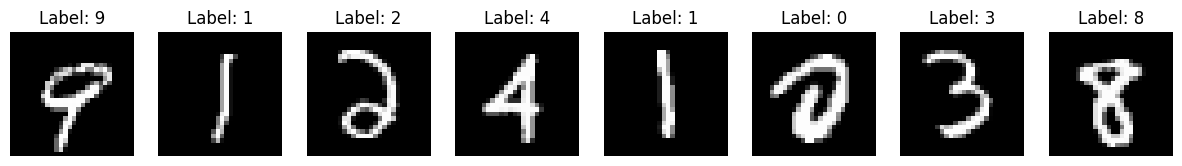

In [26]:
fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')  # grayscale
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')

plt.show()


In [27]:
class TeacherMLP(nn.Module):
    def __init__(self,hidden1=256,hidden2=128):
        super().__init__()
        self.net=nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28,hidden1),
            nn.ReLU(),
            nn.Linear(hidden1,hidden2),
            nn.ReLU(),
            nn.Linear(hidden2,10)
        )
    def forward(self,x):
        return self.net(x)

In [28]:
teacher=TeacherMLP(hidden1=256,hidden2=128)

In [29]:
print(teacher)

TeacherMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [30]:
def train_teacher(model,loader,epochs=3,lr=0.001):
    opt=optim.AdamW(model.parameters(),lr=lr)
    loss_fn=nn.CrossEntropyLoss()
    model.train()

    for ep in range(epochs):
        total_loss=0
        for x,y in loader:
            opt.zero_grad()
            out=model(x)
            loss=loss_fn(out,y)
            loss.backward()
            opt.step()
            total_loss+=loss.item()
        print(f"Epoch {ep+1}/{epochs}, Loss: {total_loss/len(loader):.4f}")


In [31]:
train_teacher(teacher,train_loader)

Epoch 1/3, Loss: 0.3451
Epoch 2/3, Loss: 0.1564
Epoch 3/3, Loss: 0.1141


In [32]:
print(teacher.state_dict())

OrderedDict([('net.1.weight', tensor([[ 0.0228, -0.0129, -0.0122,  ..., -0.0041,  0.0258,  0.0328],
        [ 0.0044,  0.0190, -0.0267,  ..., -0.0164, -0.0300,  0.0150],
        [-0.0213,  0.0353,  0.0306,  ...,  0.0248,  0.0040,  0.0227],
        ...,
        [ 0.0283,  0.0321,  0.0391,  ...,  0.0240,  0.0240,  0.0318],
        [ 0.0103,  0.0117,  0.0110,  ..., -0.0068,  0.0182, -0.0211],
        [ 0.0172,  0.0235,  0.0413,  ...,  0.0093,  0.0315,  0.0133]])), ('net.1.bias', tensor([-0.0090,  0.0164, -0.0386, -0.0015, -0.0053,  0.0169, -0.0153, -0.0293,
        -0.0196, -0.0381, -0.0123, -0.0053, -0.0213,  0.0129, -0.0191, -0.0315,
         0.0167,  0.0174, -0.0029,  0.0258,  0.0062, -0.0059,  0.0040, -0.0180,
         0.0040, -0.0099, -0.0311,  0.0120, -0.0324,  0.0149, -0.0114, -0.0066,
        -0.0094,  0.0271,  0.0039,  0.0198, -0.0219, -0.0066,  0.0234,  0.0311,
        -0.0333, -0.0252,  0.0048, -0.0132, -0.0206, -0.0316, -0.0135, -0.0313,
        -0.0152, -0.0260, -0.0067,  0.0

In [33]:
class StudentMLP(nn.Module):
    def __init__(self,hidden=64):
        super().__init__()
        self.net=nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28,hidden),
            nn.ReLU(),
            nn.Linear(hidden,10)

        )
    def forward(self,x):
        return self.net(x)

In [34]:
student=StudentMLP(hidden=64)

In [35]:
print(student)

StudentMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [41]:
def pretrain_student(student,loader,epochs=3,lr=0.001):
    opt=optim.AdamW(student.parameters(),lr=lr)
    ce_loss=nn.CrossEntropyLoss()
    student.train()
    for ep in range(epochs):
        total_loss=0
        for x,y in loader:
            opt.zero_grad()
            out=student(x)
            loss=ce_loss(out,y)
            loss.backward()
            opt.step()
            total_loss+=loss.item()
        print(f"Epoch {ep+1}/{epochs}, Loss: {total_loss/len(loader):.4f}")

In [42]:
pretrain_student(student,train_loader,epochs=3)

Epoch 1/3, Loss: 0.4204
Epoch 2/3, Loss: 0.2491
Epoch 3/3, Loss: 0.1882


In [43]:
print(student.state_dict())

OrderedDict([('net.1.weight', tensor([[-0.0126,  0.0055, -0.0019,  ..., -0.0306, -0.0439,  0.0230],
        [ 0.0403, -0.0086,  0.0330,  ...,  0.0403, -0.0221,  0.0400],
        [ 0.0095, -0.0282,  0.0209,  ...,  0.0040, -0.0181, -0.0126],
        ...,
        [ 0.0165, -0.0355, -0.0406,  ..., -0.0509,  0.0045, -0.0303],
        [ 0.0299,  0.0195, -0.0083,  ..., -0.0291, -0.0189,  0.0251],
        [-0.0181, -0.0328, -0.0231,  ..., -0.0228,  0.0024, -0.0320]])), ('net.1.bias', tensor([-0.0243, -0.0098, -0.0310, -0.0170, -0.0173, -0.0143, -0.0022, -0.0379,
        -0.0249, -0.0313,  0.0134,  0.0303,  0.0060,  0.0331,  0.0155, -0.0345,
         0.0141, -0.0050,  0.0251,  0.0091, -0.0296, -0.0011,  0.0094, -0.0238,
         0.0226, -0.0324, -0.0236, -0.0234, -0.0195, -0.0347,  0.0024, -0.0202,
        -0.0361, -0.0020,  0.0179,  0.0124, -0.0216,  0.0252,  0.0327, -0.0220,
        -0.0215,  0.0359, -0.0124,  0.0082,  0.0190, -0.0115, -0.0361, -0.0059,
         0.0216, -0.0304,  0.0311, -0.0

In [44]:
# ----- Distillation Training -----
temperature = 2.0
alpha = 0.7
ce_loss = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction="batchmean")
optimizer = optim.Adam(student.parameters(), lr=1e-3)

In [45]:
def distill(student, teacher, loader, epochs=3):
    for ep in range(epochs):

        student.train()

        total_loss = 0

        for x, y in loader:
            # Teacher outputs
            with torch.no_grad():
                t_logits = teacher(x)
                t_probs = torch.softmax(t_logits / temperature, dim=1)

            # Student outputs
            s_logits = student(x)
            s_log_probs = torch.log_softmax(s_logits / temperature, dim=1)

            # Losses
            loss_soft = kl_loss(s_log_probs, t_probs) * (temperature**2)
            loss_hard = ce_loss(s_logits, y)
            loss = alpha * loss_soft + (1 - alpha) * loss_hard

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()
        print(f"Student Epoch {ep+1}: Loss = {total_loss/len(loader):.4f}")

In [46]:
distill(student, teacher, train_loader)

Student Epoch 1: Loss = 0.1967
Student Epoch 2: Loss = 0.1443
Student Epoch 3: Loss = 0.1286


In [48]:
# ----- 5. Evaluation Function -----
def evaluate(model, loader, name="Model"):
    model.eval()

    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    acc = correct / total * 100
    print(f"{name} Accuracy: {acc:.2f}%")
    return acc

In [49]:
# Evaluate both Teacher and Student
evaluate(teacher, test_loader, "Teacher")

Teacher Accuracy: 96.14%


96.14

In [50]:
evaluate(student, test_loader, "Student")

Student Accuracy: 95.73%


95.73

In [51]:
# ----- 6. Sample Predictions -----
def predict(model, x):
    model.eval()
    with torch.no_grad():
        out = model(x)
        return out.argmax(dim=1)

In [52]:
sample_batch, sample_labels = next(iter(test_loader))

In [53]:
preds = predict(student, sample_batch)

In [54]:
print("Sample predictions (Student):", preds[:20])

Sample predictions (Student): tensor([7, 2, 1, 0, 4, 1, 4, 9, 6, 9, 0, 6, 9, 0, 1, 5, 9, 7, 8, 4])


In [55]:
print("True labels:", sample_labels[:20])

True labels: tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4])


In [56]:
# ----- 7. Save Student Model -----
torch.save(student.state_dict(), "distilled_student.pth")
print("Student model saved as distilled_student.pth")

Student model saved as distilled_student.pth
